# Global weekly EDA
Utforskar datan för alla länder i den globala topplistan.

In [59]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path

# Läs in datat
DATA_PATH = Path("../../data/processed")
df = pd.read_csv(DATA_PATH / "2026-02-08_global_weekly.csv", sep=';', encoding='utf-8')
duckdb.register("global_weekly", df)

# Stil för matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

### Skapar querys och tar hjälp av duckdb

1. Vilket land har flest unika titlar i topp 10?

In [60]:
# Visar land med flest unika titlar i global_weekly
query = """
    SELECT 
        country_name,
        COUNT(DISTINCT show_title) AS unique_titles
    FROM global_weekly
    GROUP BY country_name
    ORDER BY unique_titles DESC
    LIMIT 10
"""
result = duckdb.sql(query).df()
print("=== Topp 10 länder med flest unika titlar ===\n")
for _, row in result.iterrows():
    print(f"{row['country_name']}: {row['unique_titles']} unika titlar")

=== Topp 10 länder med flest unika titlar ===

Singapore: 1951 unika titlar
New Zealand: 1950 unika titlar
Canada: 1949 unika titlar
Qatar: 1927 unika titlar
Trinidad and Tobago: 1925 unika titlar
Réunion: 1914 unika titlar
United Arab Emirates: 1901 unika titlar
Uruguay: 1898 unika titlar
Bahrain: 1892 unika titlar
Bahamas: 1883 unika titlar


2. Vilka titlar är mest globalt spridda?

In [61]:
# Sammanfattar global spridning av titlar med cumulative_weeks_in_top_10
query = """
    SELECT 
        show_title,
        COUNT(DISTINCT country_name) AS antal_lander,
        SUM(cumulative_weeks_in_top_10) AS total_veckor
    FROM global_weekly
    GROUP BY show_title
    ORDER BY antal_lander DESC, total_veckor DESC
    LIMIT 10
"""
top_global = duckdb.sql(query).df()
print("=== Mest globalt spridda titlar ===\n")
for _, row in top_global.iterrows():
    print(f"'{row['show_title']}' - {row['antal_lander']} länder, {row['total_veckor']:.0f} veckor")

=== Mest globalt spridda titlar ===

'Squid Game' - 94 länder, 26697 veckor
'Red Notice' - 94 länder, 8288 veckor
'Emily in Paris' - 94 länder, 7910 veckor
'The Witcher' - 94 länder, 7268 veckor
'You' - 94 länder, 7152 veckor
'Inventing Anna' - 94 länder, 3902 veckor
'Sex Education' - 94 länder, 3335 veckor
'All of Us Are Dead' - 94 länder, 3108 veckor
'Don't Look Up' - 94 länder, 2266 veckor
'The Tinder Swindler' - 94 länder, 1452 veckor


3. Jämför två länder – har de fler gemensamma titlar än vad som är slumpmässigt?

In [62]:
# Jämför gemensamma titlar mellan två länder
land1 = "Germany"
land2 = "France"

query = f"""
    WITH land1_titles AS (
        SELECT DISTINCT show_title FROM global_weekly WHERE country_name = '{land1}'
    ),
    land2_titles AS (
        SELECT DISTINCT show_title FROM global_weekly WHERE country_name = '{land2}'
    )
    SELECT COUNT(*) AS gemensamma FROM (
        SELECT show_title FROM land1_titles INTERSECT SELECT show_title FROM land2_titles
    )
"""
common = duckdb.sql(query).df().iloc[0,0]
print(f"=== Gemensamma titlar mellan {land1} och {land2} ===\n")
print(f"Totalt: {common} gemensamma titlar")

# Exempel på gemensamma titlar
query_ex = f"""
    SELECT show_title FROM (
        SELECT DISTINCT show_title FROM global_weekly WHERE country_name = '{land1}'
        INTERSECT
        SELECT DISTINCT show_title FROM global_weekly WHERE country_name = '{land2}'
    ) ORDER BY show_title LIMIT 10
"""
ex = duckdb.sql(query_ex).df()
print("\nExempel (10 första):")
for title in ex['show_title']:
    print(f"• {title}")

=== Gemensamma titlar mellan Germany och France ===

Totalt: 1111 gemensamma titlar

Exempel (10 första):
• 10 Days of a Good Man
• 13 Hours: The Secret Soldiers of Benghazi
• 14 Peaks: Nothing Is Impossible
• 1883
• 1899
• 1923
• 1992
• 2 Hearts
• 28 Weeks Later
• 3 Body Problem


4. Vilket land har högst andel film jämfört med tv-serier?

In [63]:
# Analyserar andelen filmer vs TV-serier i topp 10 per land
query = """
    SELECT 
        country_name,
        SUM(CASE WHEN category = 'Films' THEN cumulative_weeks_in_top_10 ELSE 0 END) AS film_weeks,
        SUM(CASE WHEN category = 'TV' THEN cumulative_weeks_in_top_10 ELSE 0 END) AS tv_weeks
    FROM global_weekly
    GROUP BY country_name
    HAVING film_weeks + tv_weeks > 0
"""
result = duckdb.sql(query).df()
result['film_pct'] = result['film_weeks'] / (result['film_weeks'] + result['tv_weeks'])
result = result.sort_values('film_pct', ascending=False).head(10)

print("=== Topp 10 länder med högst filmandel ===\n")
for _, row in result.iterrows():
    print(f"{row['country_name']}: {row['film_pct']:.0%} film ({row['film_weeks']:.0f} veckor), {row['tv_weeks']:.0f} veckor TV")

=== Topp 10 länder med högst filmandel ===

Latvia: 53% film (10443 veckor), 9448 veckor TV
Iceland: 52% film (7805 veckor), 7085 veckor TV
Slovakia: 51% film (8985 veckor), 8487 veckor TV
United States: 49% film (7773 veckor), 7943 veckor TV
Czech Republic: 49% film (8941 veckor), 9340 veckor TV
United Kingdom: 48% film (6650 veckor), 7238 veckor TV
Estonia: 48% film (8124 veckor), 8855 veckor TV
Canada: 48% film (5841 veckor), 6392 veckor TV
Vietnam: 47% film (10893 veckor), 12519 veckor TV
Lithuania: 46% film (8508 veckor), 9870 veckor TV


### Visualisera querys i grafer och diagram

1. Vilket land har flest unika titlar i topp 10?

=== Topp 10 länder med flest unika titlar ===

        country_name  unique_titles
           Singapore           1951
         New Zealand           1950
              Canada           1949
               Qatar           1927
 Trinidad and Tobago           1925
             Réunion           1914
United Arab Emirates           1901
             Uruguay           1898
             Bahrain           1892
             Bahamas           1883


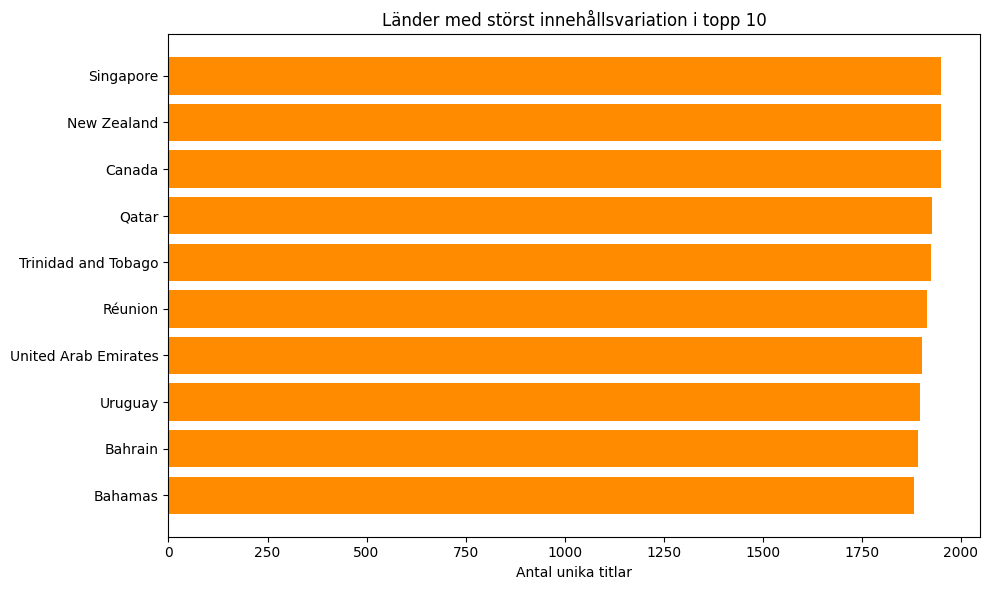

In [64]:
# Visar länder med flest unika titlar i topp 10 i show_title
query = """
    SELECT 
        country_name,
        COUNT(DISTINCT show_title) AS unique_titles
    FROM global_weekly
    GROUP BY country_name
    ORDER BY unique_titles DESC
    LIMIT 10
"""
top_unique = duckdb.sql(query).df()
print("=== Topp 10 länder med flest unika titlar ===\n")
print(top_unique.to_string(index=False))

plt.barh(top_unique['country_name'], top_unique['unique_titles'], color='darkorange')
plt.xlabel('Antal unika titlar')
plt.title('Länder med störst innehållsvariation i topp 10')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

2. Vilket land har högst andel film jämfört med TV?

=== Topp 10 länder med högst filmandel ===

  country_name  film_pct  film_weeks  tv_weeks
        Latvia  0.525011     10443.0    9448.0
       Iceland  0.524177      7805.0    7085.0
      Slovakia  0.514251      8985.0    8487.0
 United States  0.494591      7773.0    7943.0
Czech Republic  0.489087      8941.0    9340.0
United Kingdom  0.478831      6650.0    7238.0
       Estonia  0.478473      8124.0    8855.0
        Canada  0.477479      5841.0    6392.0
       Vietnam  0.465274     10893.0   12519.0
     Lithuania  0.462945      8508.0    9870.0


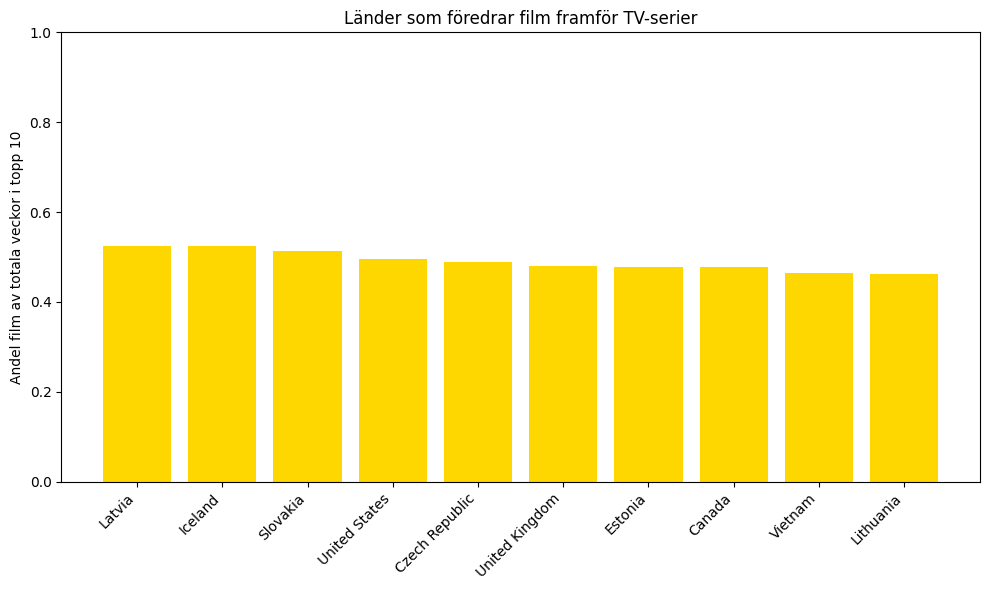

In [65]:
# Analyserar andelen filmer vs TV-serier i topp 10 per land från tabellen global_weekly
query = """
    SELECT 
        country_name,
        SUM(CASE WHEN category = 'Films' THEN cumulative_weeks_in_top_10 ELSE 0 END) AS film_weeks,
        SUM(CASE WHEN category = 'TV' THEN cumulative_weeks_in_top_10 ELSE 0 END) AS tv_weeks
    FROM global_weekly
    GROUP BY country_name
    HAVING film_weeks + tv_weeks > 0
"""
result = duckdb.sql(query).df()
result['film_pct'] = result['film_weeks'] / (result['film_weeks'] + result['tv_weeks'])
result = result.sort_values('film_pct', ascending=False).head(10)

print("=== Topp 10 länder med högst filmandel ===\n")
print(result[['country_name', 'film_pct', 'film_weeks', 'tv_weeks']].to_string(index=False))

plt.bar(result['country_name'], result['film_pct'], color='gold')
plt.ylabel('Andel film av totala veckor i topp 10')
plt.title('Länder som föredrar film framför TV-serier')
plt.xticks(rotation=45, ha='right')
plt.ylim(0,1)
plt.tight_layout()
plt.show()

3. Andel film per land i procentform

Andel film per land (topp 10):
  country_name film_pct
        Latvia      53%
       Iceland      52%
      Slovakia      51%
 United States      49%
Czech Republic      49%
United Kingdom      48%
       Estonia      48%
        Canada      48%
       Vietnam      47%
     Lithuania      46%


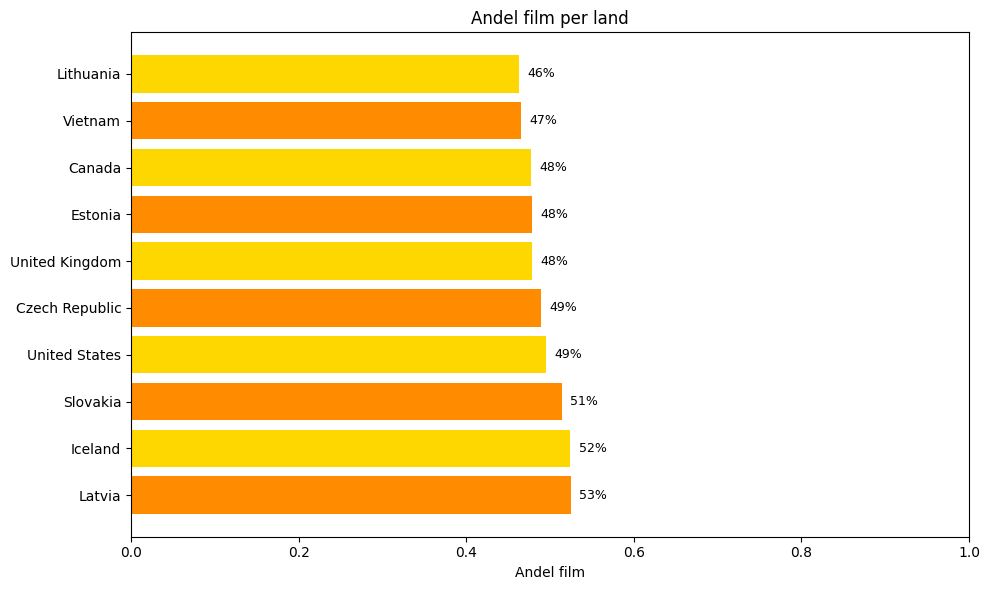

In [66]:
# Skapar en lista med land och filmandel, lägger till etiketter
heat_data = result[['country_name', 'film_pct']].copy()
heat_data['film_pct'] = heat_data['film_pct'].apply(lambda x: f"{x:.0%}")
print("Andel film per land (topp 10):")
print(heat_data.to_string(index=False))

colors = ['darkorange', 'gold'] * (len(result) // 2 + 1)
colors = colors[:len(result)]

bars = plt.barh(result['country_name'], result['film_pct'], color=colors)
plt.xlabel('Andel film')
plt.title('Andel film per land')

for bar, pct in zip(bars, result['film_pct']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{pct:.0%}', 
             va='center', fontsize=9)
plt.xlim(0,1)
plt.tight_layout()
plt.show()

## Sammanfattning
Vad datan säger.
- *Innehållsvariation*: Singapore har flest unika titlar som 1951, följt av Nya Zeeland och Kanada.
- *Global spridning*: "Squid Game" och "Red Notice" förekommer i flest länder.
- *Kulturell överlappning*: Tyskland och Frankrike delar över 1100 gemensamma titlar.
- *Film vs TV*: Lettland 53% och Island 52% har högst filmandel.
- *Långlivade titlar*: "Squid Game" är den titel med flest totala veckor globalt.